## Importing Libraries

In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

## Data Loading

In [183]:
df = pd.read_csv("Life Expectancy Data.csv")

## Basic Data Inspection and Cleaning

In [184]:
df.head() # First 5 rows

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [185]:
df.shape # Shape of data

(2938, 22)

In [186]:
df.info() # Info of data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [187]:
df.describe() #Statistical summary

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [188]:
# Checking for null values

df.isnull().sum() 

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [189]:
# Cleaning data column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [190]:
df

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [191]:
#Dropping null values in 'life_expectancy' and 'adult_mortality' columns
df = df.dropna(subset = ["life_expectancy", "adult_mortality"])

In [192]:
df[df["alcohol"].isnull()]

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
32,Algeria,2015,Developing,75.6,19.0,21,NaN,0.0,95.0,63,...,95.0,NaN,95.0,0.1,4132.762920,39871528.0,6.0,5.8,0.743,14.4
48,Angola,2015,Developing,52.4,335.0,66,NaN,0.0,64.0,118,...,7.0,NaN,64.0,1.9,3695.793748,2785935.0,8.3,8.2,0.531,11.4
64,Antigua and Barbuda,2015,Developing,76.4,13.0,0,NaN,0.0,99.0,0,...,86.0,NaN,99.0,0.2,13566.954100,NaN,3.3,3.3,0.784,13.9
80,Argentina,2015,Developing,76.3,116.0,8,NaN,0.0,94.0,0,...,93.0,NaN,94.0,0.1,13467.123600,43417765.0,1.0,0.9,0.826,17.3
96,Armenia,2015,Developing,74.8,118.0,1,NaN,0.0,94.0,33,...,96.0,NaN,94.0,0.1,369.654776,291695.0,2.1,2.2,0.741,12.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2858,Venezuela (Bolivarian Republic of),2015,Developing,74.1,157.0,9,NaN,0.0,87.0,0,...,87.0,NaN,87.0,0.1,NaN,NaN,1.6,1.5,0.769,14.3
2874,Viet Nam,2015,Developing,76.0,127.0,28,NaN,0.0,97.0,256,...,97.0,NaN,97.0,0.1,NaN,NaN,14.2,14.5,0.678,12.6
2890,Yemen,2015,Developing,65.7,224.0,37,NaN,0.0,69.0,468,...,63.0,NaN,69.0,0.1,NaN,NaN,13.6,13.4,0.499,9.0
2906,Zambia,2015,Developing,61.8,33.0,27,NaN,0.0,9.0,9,...,9.0,NaN,9.0,4.1,1313.889646,161587.0,6.3,6.1,0.576,12.5


In [193]:
# Filling null values with country median for 'alcohol' column

df['alcohol'] = df.groupby('country')['alcohol'].transform(
    lambda x: x.fillna(x.median()))

df['alcohol'] = df['alcohol'].fillna(
    df.groupby('status')['alcohol'].transform('median'))

c:\Users\Harijith\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Harijith\AppData\Local\Temp\ipykernel_25908\3910057062.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['alcohol'] = df.groupby('country')['alcohol'].transform(
C:\Users\Harijith\AppData\Local\Temp\ipykernel_25908\3910057062.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['alcohol'] = df['alcohol'].fillna(


In [194]:
df.columns

Index(['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b',
       'measles', 'bmi', 'under-five_deaths', 'polio', 'total_expenditure',
       'diphtheria', 'hiv/aids', 'gdp', 'population', 'thinness__1-19_years',
       'thinness_5-9_years', 'income_composition_of_resources', 'schooling'],
      dtype='object')

In [195]:
# Filling null values with country wise median

columns = [
    'hepatitis_b',
    'bmi',
    'polio',
    'total_expenditure',
    'diphtheria',
    'gdp',
    'population',
    'thinness__1-19_years',
    'thinness_5-9_years',
    'income_composition_of_resources',
    'schooling'
]

for col in columns:
    df[col] = df.groupby('country')[col].transform(
        lambda x: x.fillna(x.median())    )

c:\Users\Harijith\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Harijith\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Harijith\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Harijith\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Harijith\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\Harijith\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, ou

In [196]:
gdp_missing_countries = df.groupby('country')['gdp'].apply(lambda x: x.isnull().all())
print(gdp_missing_countries[gdp_missing_countries])

country
Bahamas                                                 True
Bolivia (Plurinational State of)                        True
Congo                                                   True
Czechia                                                 True
Côte d'Ivoire                                           True
Democratic People's Republic of Korea                   True
Democratic Republic of the Congo                        True
Egypt                                                   True
Gambia                                                  True
Iran (Islamic Republic of)                              True
Kyrgyzstan                                              True
Lao People's Democratic Republic                        True
Micronesia (Federated States of)                        True
Republic of Korea                                       True
Republic of Moldova                                     True
Saint Lucia                                             True
Saint Vincent an

In [197]:
population_missing_countries = df.groupby('country')['population'].apply(lambda x: x.isnull().all())
print(population_missing_countries[population_missing_countries])

country
Antigua and Barbuda                                     True
Bahamas                                                 True
Bahrain                                                 True
Barbados                                                True
Bolivia (Plurinational State of)                        True
Brunei Darussalam                                       True
Congo                                                   True
Cuba                                                    True
Czechia                                                 True
Côte d'Ivoire                                           True
Democratic People's Republic of Korea                   True
Democratic Republic of the Congo                        True
Egypt                                                   True
Gambia                                                  True
Grenada                                                 True
Iran (Islamic Republic of)                              True
Kuwait          

In [198]:
cols = ['hepatitis_b',
    'bmi',
    'gdp',
    'population',
    'total_expenditure',
    'income_composition_of_resources',
    'thinness__1-19_years',
    'thinness_5-9_years',
    'schooling'
]

for col in cols:
    df[col] = df[col].fillna(df.groupby('status')[col].transform('median'))

C:\Users\Harijith\AppData\Local\Temp\ipykernel_25908\1777976370.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df.groupby('status')[col].transform('median'))
C:\Users\Harijith\AppData\Local\Temp\ipykernel_25908\1777976370.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df.groupby('status')[col].transform('median'))
C:\Users\Harijith\AppData\Local\Temp\ipykernel_25908\1777976370.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy 

In [199]:
df.isnull().sum()

country                            0
year                               0
status                             0
life_expectancy                    0
adult_mortality                    0
infant_deaths                      0
alcohol                            0
percentage_expenditure             0
hepatitis_b                        0
measles                            0
bmi                                0
under-five_deaths                  0
polio                              0
total_expenditure                  0
diphtheria                         0
hiv/aids                           0
gdp                                0
population                         0
thinness__1-19_years               0
thinness_5-9_years                 0
income_composition_of_resources    0
schooling                          0
dtype: int64

In [200]:
df.duplicated().sum()

0

## Exploratory Data Analysis

Target Distribution

c:\Users\Harijith\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


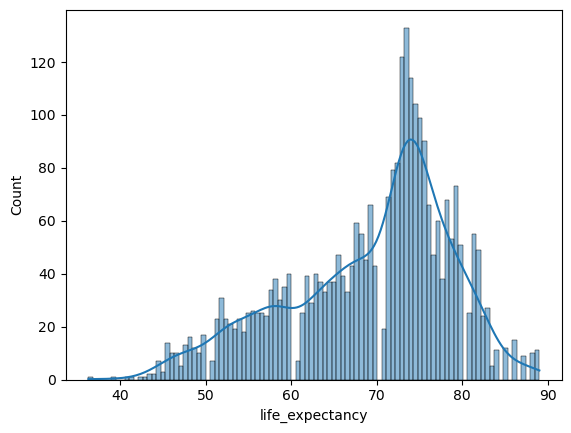

In [201]:
sns.histplot(data= df, x= 'life_expectancy', kde=True, bins = 100)
plt.show()

Top Countries by Life Expectancy

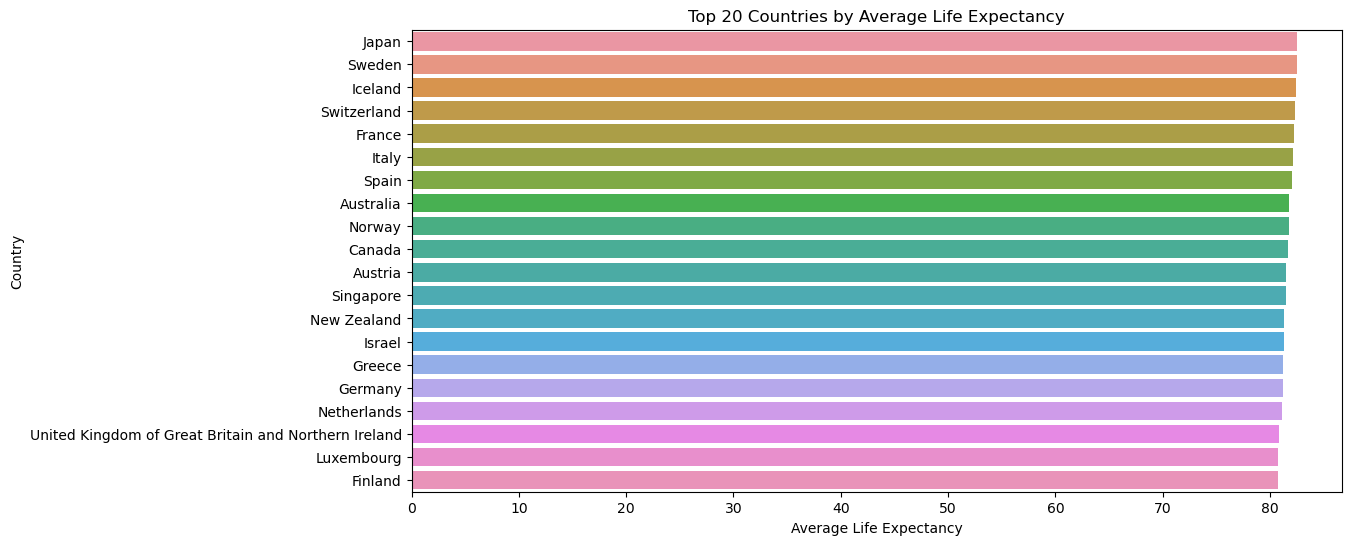

In [202]:
country_life = (df.groupby('country')['life_expectancy'].mean().sort_values(ascending=False).head(20))
plt.figure(figsize=(12,6))
sns.barplot(
    x=country_life.values,
    y=country_life.index
)

plt.title('Top 20 Countries by Average Life Expectancy')
plt.xlabel('Average Life Expectancy')
plt.ylabel('Country')
plt.show()

Countries With Least Life Expectancy

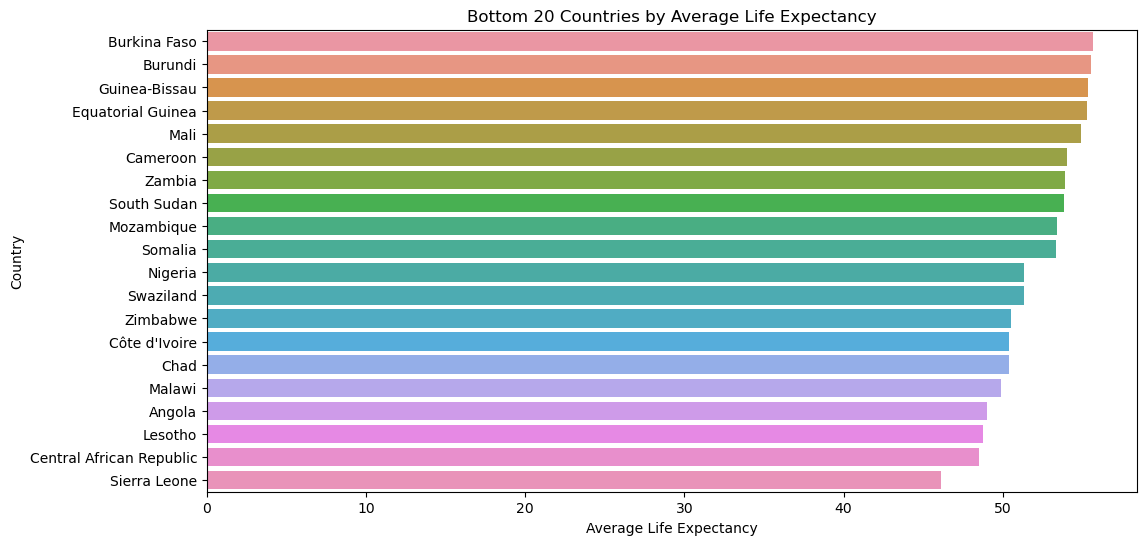

In [203]:
country_life = (df.groupby('country')['life_expectancy'].mean().sort_values(ascending= False).tail(20))

plt.figure(figsize=(12,6))
sns.barplot(x=country_life.values, y=country_life.index)
plt.title('Bottom 20 Countries by Average Life Expectancy')
plt.xlabel('Average Life Expectancy')
plt.ylabel('Country')
plt.show()

Life Expectancy Based on Country Status

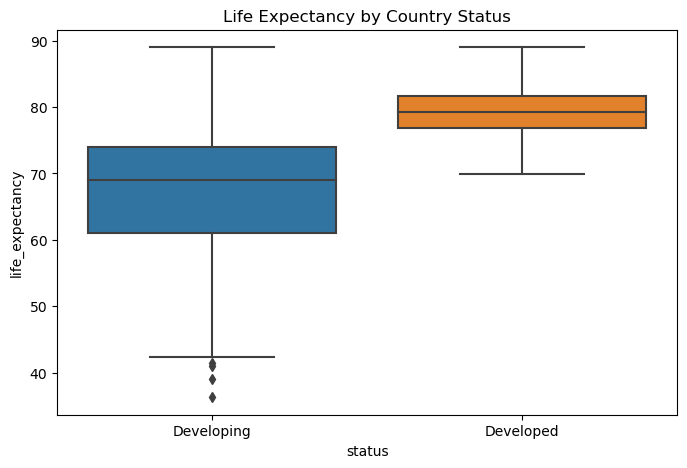

In [204]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='status', y='life_expectancy')
plt.title('Life Expectancy by Country Status')
plt.show()

Life Expectancy Based on GDP and Status

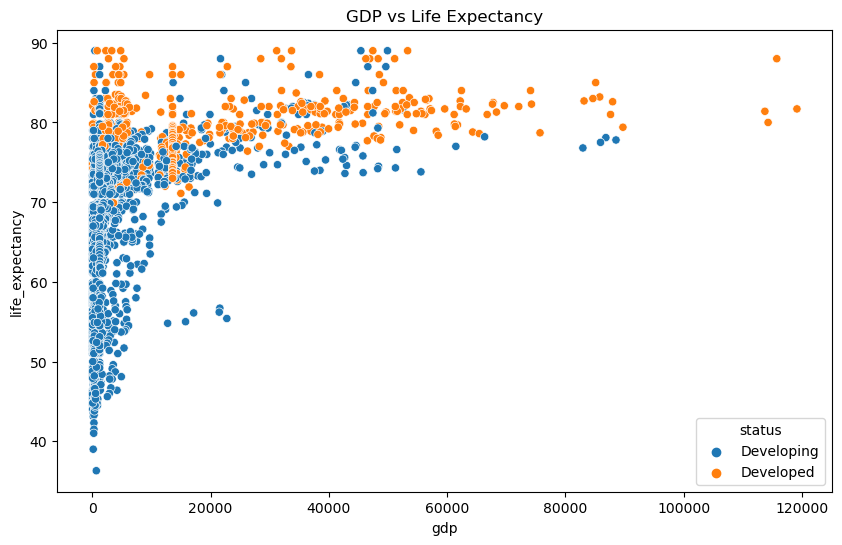

In [205]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='gdp', y='life_expectancy', hue='status')
plt.title('GDP vs Life Expectancy')
plt.show()

Life Expectancy Based on Schooling and Status

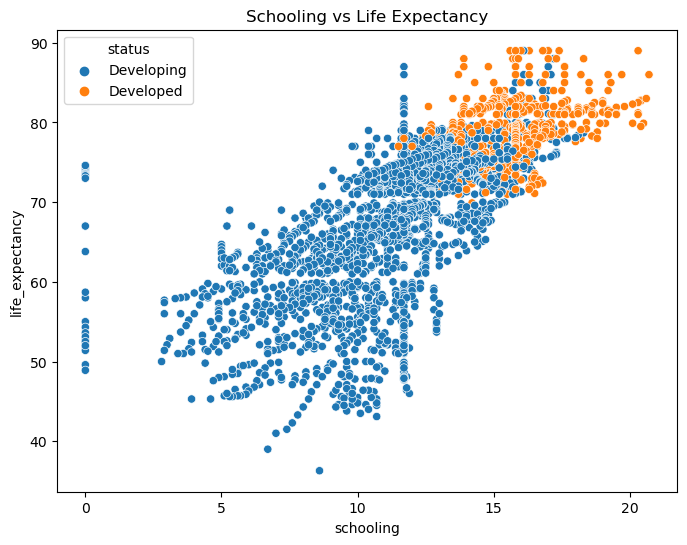

In [206]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='schooling', y='life_expectancy', hue='status')
plt.title('Schooling vs Life Expectancy')
plt.show()

Adult Mortality vs Life Expectancy

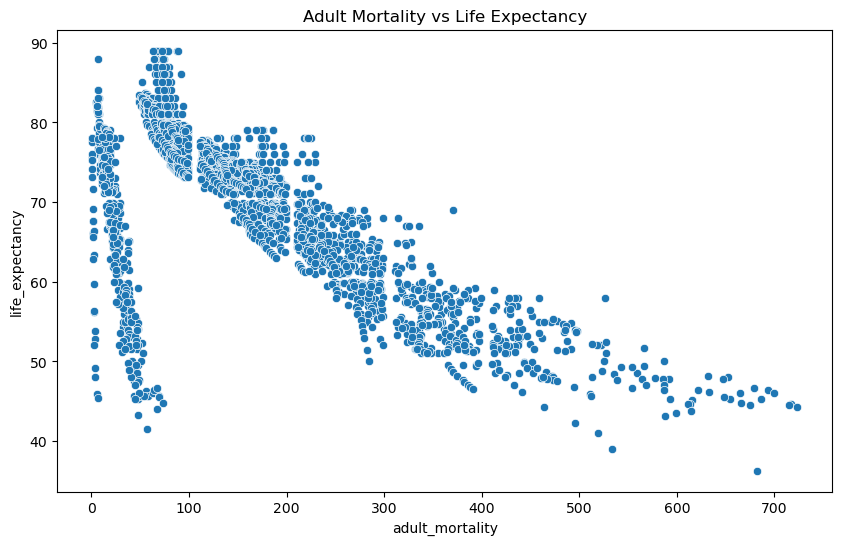

In [207]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x='adult_mortality', y='life_expectancy')

plt.title('Adult Mortality vs Life Expectancy')
plt.show()

Correlation Heatmap

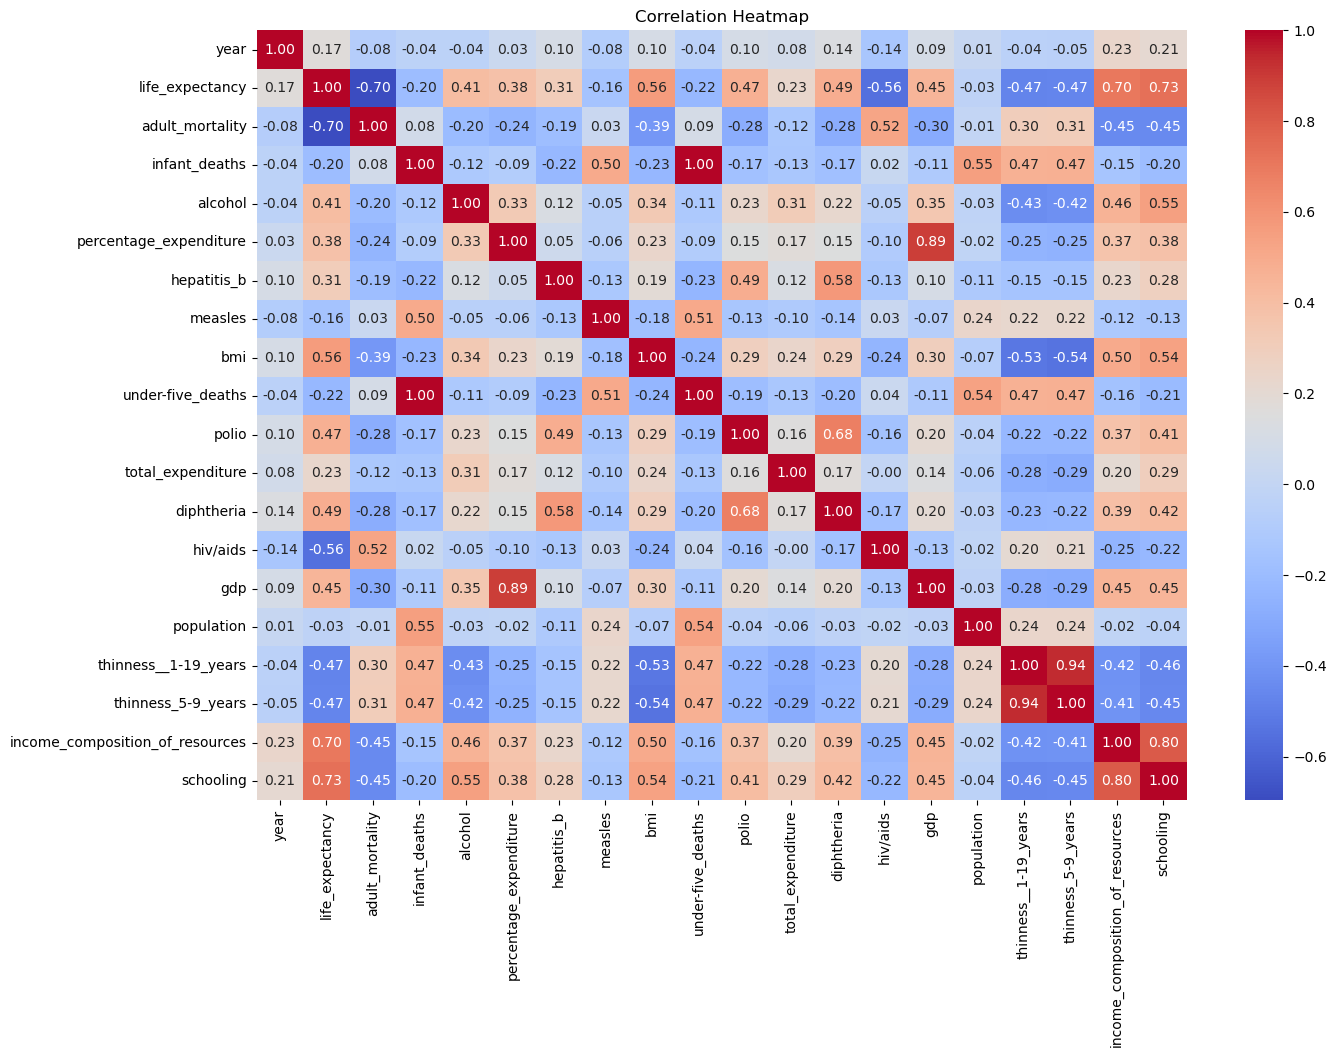

In [208]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

Countries With Most Increase in Life Expectancy

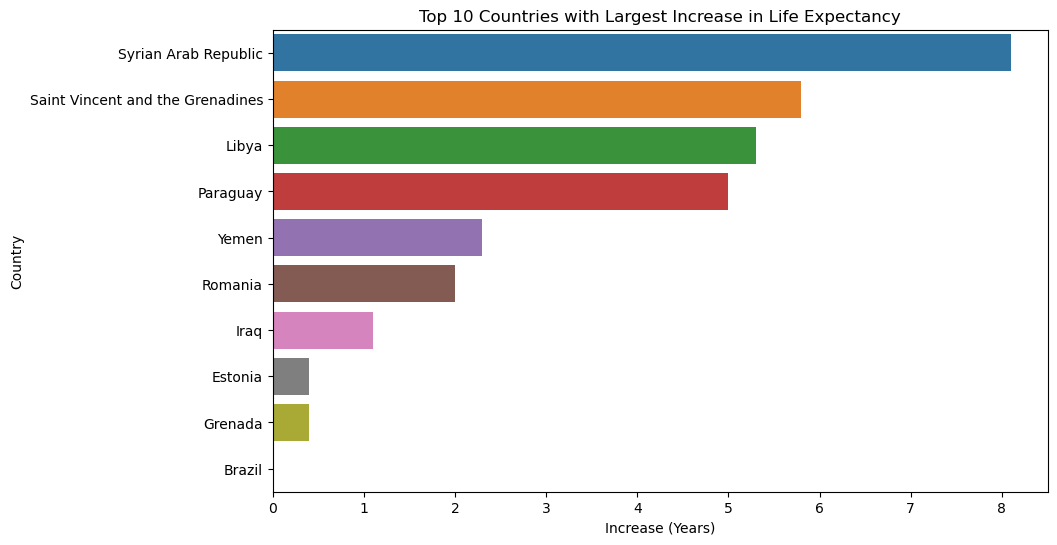

In [209]:
country_change = (df.groupby('country')['life_expectancy'].agg(['first', 'last']))

country_change['improvement'] = country_change['last'] - country_change['first']
top_improvement = country_change.sort_values(by='improvement', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_improvement['improvement'], y=top_improvement.index)
plt.title('Top 10 Countries with Largest Increase in Life Expectancy')
plt.xlabel('Increase (Years)')
plt.ylabel('Country')
plt.show()

Global Life Expectancy Trend

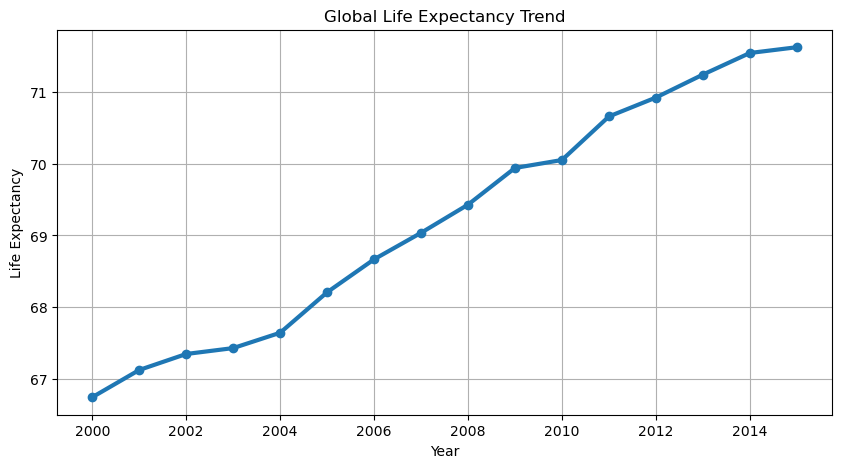

In [210]:
yearly = df.groupby('year')['life_expectancy'].mean()
plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly.values, linewidth=3, marker='o')

plt.title('Global Life Expectancy Trend')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.grid(True)

plt.show()

In [211]:
pip install pycountry pycountry-convert

Note: you may need to restart the kernel to use updated packages.


In [212]:
# Feature Engineering to create a continent column using country name
import pycountry
import pycountry_convert as pc
def get_continent(country_name):
    try:
        # Handling special country names in the dataset
        country_mapping = {
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Brunei Darussalam': 'Brunei',
    'Cabo Verde': 'Cape Verde',
    "Côte d'Ivoire": 'Ivory Coast',
    'Czechia': 'Czech Republic',
    'Democratic People\'s Republic of Korea': 'North Korea',
    'Democratic Republic of the Congo': 'Congo',
    'Iran (Islamic Republic of)': 'Iran',
    'Lao People\'s Democratic Republic': 'Laos',
    'Micronesia (Federated States of)': 'Micronesia',
    'Republic of Korea': 'South Korea',
    'Republic of Moldova': 'Moldova',
    'Russian Federation': 'Russia',
    'Swaziland': 'Eswatini',
    'Syrian Arab Republic': 'Syria',
    'The former Yugoslav republic of Macedonia': 'North Macedonia',
    'Timor-Leste': 'East Timor',
    'Turkey': 'Türkiye',
    'United Republic of Tanzania': 'Tanzania',
    'United States of America': 'United States',
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
    'Viet Nam': 'Vietnam'
}

        country_name = country_mapping.get(country_name, country_name)

        country = pycountry.countries.lookup(country_name)

        continent_code = pc.country_alpha2_to_continent_code(country.alpha_2)

        continent = {
            'AF': 'Africa',
            'AS': 'Asia',
            'EU': 'Europe',
            'NA': 'North America',
            'SA': 'South America',
            'OC': 'Oceania'
        }

        return continent.get(continent_code, 'Unknown')

    except:
        return 'Unknown'

In [213]:
df['continent'] = df['country'].apply(get_continent)

C:\Users\Harijith\AppData\Local\Temp\ipykernel_25908\3195778283.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['continent'] = df['country'].apply(get_continent)


In [214]:
df[df['continent'] == 'Unknown']['country'].unique()

array(['Brunei Darussalam', "Côte d'Ivoire", 'Cabo Verde',
       'Micronesia (Federated States of)', 'Russian Federation',
       'Timor-Leste'], dtype=object)

Life Expectancy by Continent

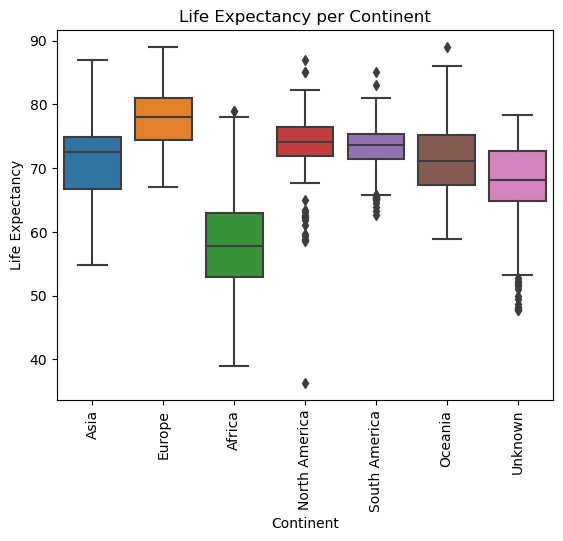

In [215]:
sns.boxplot(data=df, x='continent', y='life_expectancy')
plt.xticks(rotation= 90)
plt.xlabel("Continent")
plt.ylabel("Life Expectancy")
plt.title("Life Expectancy per Continent")
plt.show()

## Feature Engineering

In [216]:
# Log transforming highle skewed columns
skewed_cols = ['gdp', 'population', 'percentage_expenditure', 'measles']

for col in skewed_cols:
    df[col] = np.log1p(df[col])

C:\Users\Harijith\AppData\Local\Temp\ipykernel_25908\1468431452.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = np.log1p(df[col])


In [217]:
# Creating a vaccination coverage column from different vaccines
df['avg_vaccination'] = (df['hepatitis_b'] + df['polio'] + df['diphtheria']) / 3

C:\Users\Harijith\AppData\Local\Temp\ipykernel_25908\4244759715.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['avg_vaccination'] = (df['hepatitis_b'] + df['polio'] + df['diphtheria']) / 3


In [218]:
# Creating average thinness column
df['avg_thinness'] = (df['thinness__1-19_years'] + df['thinness_5-9_years']) / 2

C:\Users\Harijith\AppData\Local\Temp\ipykernel_25908\3285989434.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['avg_thinness'] = (df['thinness__1-19_years'] + df['thinness_5-9_years']) / 2


In [219]:
# Creating bmi categories from bmi values
df['bmi_category'] = pd.cut(df['bmi'], bins=[0,18.5,25,30,100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

C:\Users\Harijith\AppData\Local\Temp\ipykernel_25908\2819213820.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bmi_category'] = pd.cut(df['bmi'], bins=[0,18.5,25,30,100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])


Encoding variables

In [220]:
# Encoding `status`
df['status'] = df['status'].map({'Developing': 0, 'Developed': 1})

# One hot encoding 'continent' and 'bmi_category'
df = pd.get_dummies(df, columns=['continent', 'bmi_category'], drop_first=True, dtype=int)

C:\Users\Harijith\AppData\Local\Temp\ipykernel_25908\2488726585.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['status'] = df['status'].map({'Developing': 0, 'Developed': 1})


Final Dataset

In [221]:
df.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,avg_thinness,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,continent_Unknown,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,Afghanistan,2015,0,65.0,263.0,62,0.01,4.280542,65.0,7.051856,...,17.25,1,0,0,0,0,0,1,0,0
1,Afghanistan,2014,0,59.9,271.0,64,0.01,4.311116,62.0,6.200509,...,17.50,1,0,0,0,0,0,1,0,0
2,Afghanistan,2013,0,59.9,268.0,66,0.01,4.307023,64.0,6.066108,...,17.70,1,0,0,0,0,0,0,0,0
3,Afghanistan,2012,0,59.5,272.0,69,0.01,4.371777,67.0,7.933080,...,17.95,1,0,0,0,0,0,0,0,0
4,Afghanistan,2011,0,59.2,275.0,71,0.01,2.091507,68.0,8.011023,...,18.20,1,0,0,0,0,0,0,0,0


In [222]:
df.columns

Index(['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b',
       'measles', 'bmi', 'under-five_deaths', 'polio', 'total_expenditure',
       'diphtheria', 'hiv/aids', 'gdp', 'population', 'thinness__1-19_years',
       'thinness_5-9_years', 'income_composition_of_resources', 'schooling',
       'avg_vaccination', 'avg_thinness', 'continent_Asia', 'continent_Europe',
       'continent_North America', 'continent_Oceania',
       'continent_South America', 'continent_Unknown', 'bmi_category_Normal',
       'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

## Feature Selection

In [223]:
X = df.drop(columns=['life_expectancy',
    'country',
    'year',
    'infant_deaths',
    'thinness__1-19_years',
    'thinness_5-9_years',
    'hepatitis_b',
    'polio',
    'diphtheria'])

y = df['life_expectancy']

In [224]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

## Feature Scaling

In [225]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression

In [226]:
# Import required libraries

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# Creating Linear Regression model

lr_model = LinearRegression()

In [227]:
# Training the model

lr_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Model Coefficients

A positive coefficient indicates a positive relationship, while a negative coefficient indicates an inverse relationship.

In [228]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False,
    inplace=True
)

coefficients

,Feature,Coefficient
16,continent_Europe,2.114914
12,schooling,1.821149
15,continent_Asia,1.817115
17,continent_North America,1.794904
11,income_composition_of_resources,1.273867
19,continent_South America,1.115817
13,avg_vaccination,0.987166
18,continent_Oceania,0.691121
9,gdp,0.662162
22,bmi_category_Overweight,0.643717


In [229]:
# Model Prediction
y_pred = lr_model.predict(X_test_scaled)

In [230]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R² Score : {r2:.4f}")

MAE  : 2.826
MSE  : 13.584
RMSE : 3.686
R² Score : 0.8430


In [231]:
# Actual vs Predicted Values

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head(10)

,Actual,Predicted
2399,56.5,54.060275
196,73.0,69.642875
2316,82.5,81.090139
1735,75.6,77.642209
1102,53.0,54.915545
1194,65.2,62.997125
1507,72.4,68.807529
1161,74.1,77.231542
322,77.0,76.804461
1352,67.8,74.313961


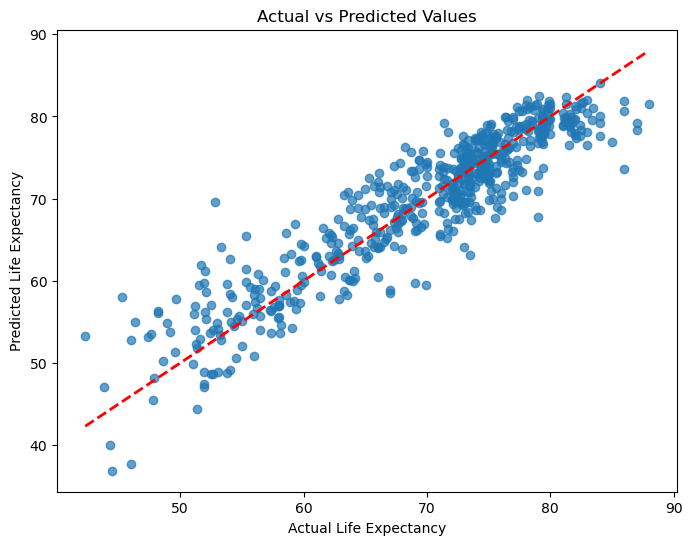

In [232]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot([y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted Values")

plt.show()

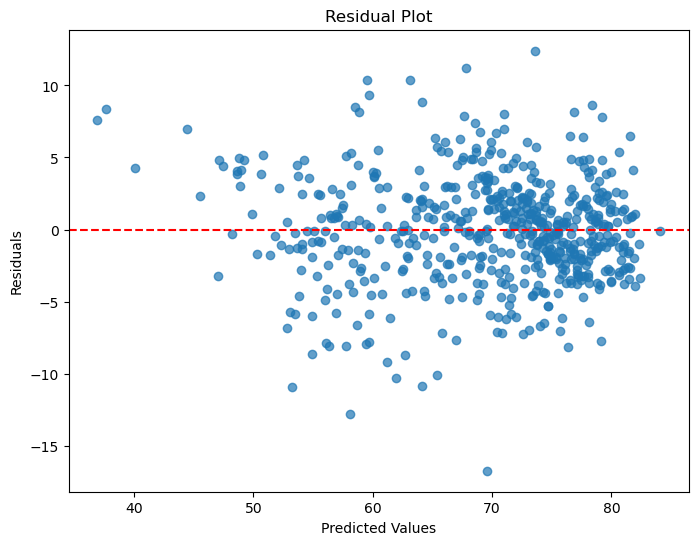

In [233]:
# Residual Analysis
# Residual = Actual − Predicted

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## Random Forest Regression

In [234]:
from sklearn.ensemble import RandomForestRegressor

# Initializing Random Forest model

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [235]:
# Train the model

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [236]:
# Model Prediction

y_pred = rf_model.predict(X_test)

In [237]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R² Score : {r2:.4f}")

MAE  : 1.052
MSE  : 2.842
RMSE : 1.686
R² Score : 0.9671


In [238]:
#  Actual vs Predicted Values

results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results.head(10)

,Actual,Predicted
2399,56.5,55.417
196,73.0,69.947
2316,82.5,82.295
1735,75.6,75.898
1102,53.0,53.710
1194,65.2,65.321
1507,72.4,73.283
1161,74.1,74.012
322,77.0,75.863
1352,67.8,68.254


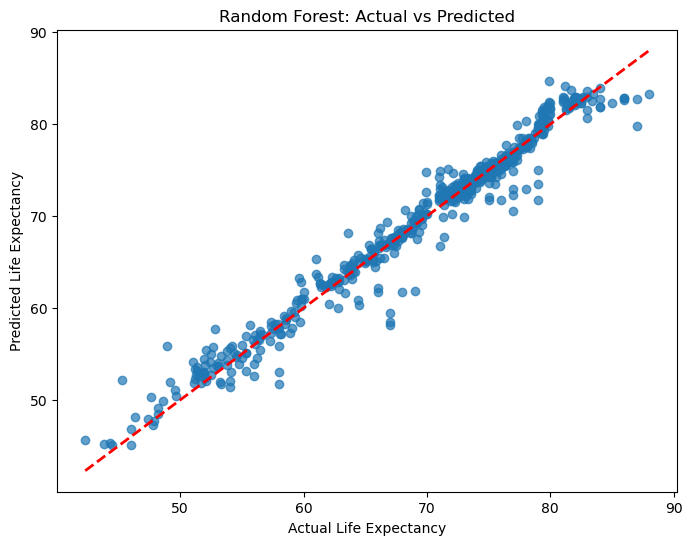

In [239]:
# Plotting Actual vs Predicted

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

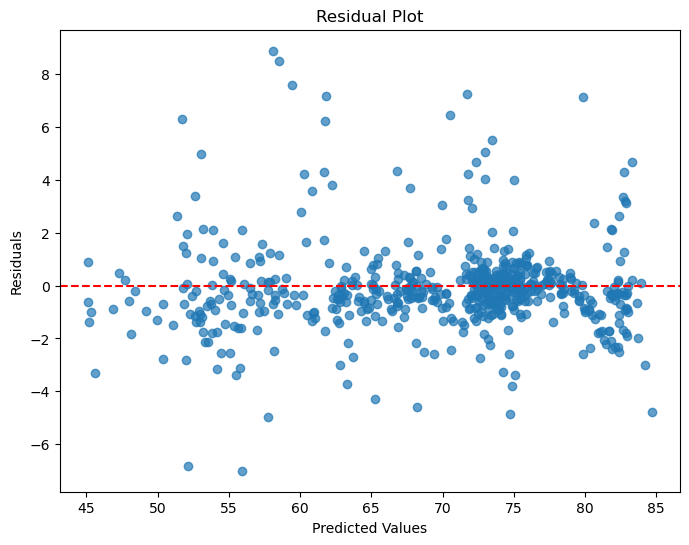

In [240]:
# Residual Analysis

residuals = y_test - y_pred
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [241]:
# Feature Importance

# Estimating the contribution of each feature toward predicting life expectancy.

feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
8,hiv/aids,0.587318
11,income_composition_of_resources,0.192081
1,adult_mortality,0.115474
5,bmi,0.018173
6,under-five_deaths,0.017702
12,schooling,0.014529
14,avg_thinness,0.011905
2,alcohol,0.008738
7,total_expenditure,0.005564
13,avg_vaccination,0.005334
